In [76]:
import getpass
import json
import sqlite3
import subprocess
from datetime import UTC, datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from skyfield.api import EarthSatellite, load, wgs84

In [77]:
target_observation = Path("/Users/tedvtorov/Desktop/ROSARP-OBS/1790853877_20261001T112437Z_59051")

In [78]:
with open(target_observation / "metadata.json") as f:
    metadata = json.load(f)
    print(metadata)

{'job_id': '12e2ba40-f851-4352-b38b-0c52bb786a3c', 'norad_id': 59051, 'aos': '2026-10-01T11:24:37.520197+00:00', 'los': '2026-10-01T11:40:05.865835+00:00', 'f_center': 137900000.0, 'decimation': 16, 'f_sample': 150000.0, 'omm_snapshot_id': 24}


In [79]:
conn = sqlite3.connect("satcap.db")
conn.row_factory = sqlite3.Row
conn.execute("PRAGMA foreign_keys = ON")
omm_snapshot = conn.execute("SELECT * FROM omm_snapshots WHERE id = ?", (metadata["omm_snapshot_id"],)).fetchone()
columns = conn.execute("PRAGMA table_info(omm_snapshots)").fetchall()
column_names = [col[1] for col in columns]
omm = list(zip(column_names, list(omm_snapshot), strict=True))
print(omm)
conn.close()

[('id', 24), ('norad_id', 59051), ('fetched_at', '2026-09-30T14:40:23.645926Z'), ('epoch', '2026-09-30T06:34:32.868192'), ('ccsds_omm_vers', '3.0'), ('comment', 'GENERATED VIA SPACE-TRACK.ORG API'), ('creation_date', '2026-09-30T10:32:28'), ('originator', '18 SPCS'), ('object_name', 'METEOR M2-4'), ('object_id', '2024-039A'), ('center_name', 'EARTH'), ('ref_frame', 'TEME'), ('time_system', 'UTC'), ('mean_element_theory', 'SGP4'), ('mean_motion', 14.22438663), ('eccentricity', 0.00062053), ('inclination', 98.7148), ('ra_of_asc_node', 231.311), ('arg_of_pericenter', 219.8161), ('mean_anomaly', 140.2562), ('ephemeris_type', 0), ('classification_type', 'U'), ('norad_cat_id', 59051), ('element_set_no', 999), ('rev_at_epoch', 13420), ('bstar', 1.7165713e-05), ('mean_motion_dot', -6e-08), ('mean_motion_ddot', 0.0), ('semimajor_axis', 7195.254), ('period', 101.235), ('apoapsis', 821.584), ('periapsis', 812.654), ('object_type', 'PAYLOAD'), ('rcs_size', 'LARGE'), ('country_code', 'CIS'), ('laun

In [80]:
def parse_utc_time(value):
    """Convert an ISO-8601 timestamp or UNIX timestamp to a UTC datetime."""
    if isinstance(value, (int, float)):
        return datetime.fromtimestamp(value, tz=UTC)

    dt = datetime.fromisoformat(value.replace("Z", "+00:00"))

    dt = dt.replace(tzinfo=UTC) if dt.tzinfo is None else dt.astimezone(UTC)

    return dt


def satellite_from_omm(omm):
    """
    Construct a Skyfield EarthSatellite from OMM orbital elements.

    `omm` can be either:
        - a dict
        - a list of (key, value) tuples
    """
    if not isinstance(omm, dict):
        omm = dict(omm)

    ts = load.timescale()

    # OMM epoch is UTC and has no timezone suffix in your data.
    datetime.fromisoformat(omm["epoch"]).replace(tzinfo=UTC)

    # Skyfield's EarthSatellite constructor expects TLE lines, so construct
    # the satellite directly from the OMM elements using the SGP4 model.
    sat = EarthSatellite(
        omm["tle_line1"],
        omm["tle_line2"],
        omm["object_name"],
        ts,
    )

    return sat, ts


def doppler_track(
    metadata,
    omm,
    station_lat,
    station_lon,
    station_alt_m=0.0,
    rate_hz=10.0,
):
    """
    Generate a Doppler time/frequency series for a satellite pass.

    Returns a pandas DataFrame with:
        time        UTC datetime
        unix_time   UNIX timestamp
        range_km    satellite range from station
        range_rate_m_s  radial velocity
        doppler_hz  Doppler offset from nominal center frequency
    """

    # Normalize OMM
    if not isinstance(omm, dict):
        omm = dict(omm)

    # ------------------------------------------------------------------
    # Input metadata
    # ------------------------------------------------------------------

    aos = parse_utc_time(metadata["aos"])
    los = parse_utc_time(metadata["los"])
    f_nom = float(metadata["f_center"])

    # ------------------------------------------------------------------
    # Satellite
    # ------------------------------------------------------------------

    sat, ts = satellite_from_omm(omm)

    # Ground station
    site = wgs84.latlon(
        station_lat,
        station_lon,
        elevation_m=station_alt_m,
    )

    # ------------------------------------------------------------------
    # Time vector
    # ------------------------------------------------------------------

    duration = (los - aos).total_seconds()

    n_samples = round(duration * rate_hz) + 1

    times = [aos + timedelta(seconds=i / rate_hz) for i in range(n_samples)]

    t_sf = ts.from_datetimes(times)

    # ------------------------------------------------------------------
    # Relative satellite state
    # ------------------------------------------------------------------

    rel = (sat - site).at(t_sf)

    r_km = np.asarray(rel.position.km)
    v_km_s = np.asarray(rel.velocity.km_per_s)

    # r and v have shape (3, N)
    r_norm = np.linalg.norm(r_km, axis=0)

    dot_rv = np.einsum("ij,ij->j", r_km, v_km_s)

    # Positive = satellite moving away from station
    range_rate_km_s = dot_rv / r_norm
    range_rate_m_s = range_rate_km_s * 1000.0

    # ------------------------------------------------------------------
    # Doppler
    # ------------------------------------------------------------------

    c = 299_792_458.0

    # Same convention as your original script:
    #
    # approaching  -> positive Doppler
    # receding     -> negative Doppler
    #
    doppler_hz = -(range_rate_m_s / c) * f_nom

    # ------------------------------------------------------------------
    # Output
    # ------------------------------------------------------------------

    unix_time = np.array([t.timestamp() for t in times])

    df = pd.DataFrame(
        {
            "time": times,
            "unix_time": unix_time,
            "range_km": r_norm,
            "range_rate_m_s": range_rate_m_s,
            "doppler_hz": doppler_hz,
        }
    )

    return df

def pass_alt_az(
    metadata,
    omm,
    station_lat,
    station_lon,
    station_alt_m=0.0,
):
    """
    Generate azimuth/elevation for every second of a satellite pass.

    Returns a pandas DataFrame with:
        time        UTC datetime
        unix_time   UNIX timestamp
        elapsed_s   seconds from AOS
        az_deg      azimuth in degrees [0, 360)
        alt_deg     elevation in degrees [-90, 90]
    """

    # Normalize OMM
    if not isinstance(omm, dict):
        omm = dict(omm)

    # ------------------------------------------------------------------
    # Input metadata
    # ------------------------------------------------------------------

    aos = parse_utc_time(metadata["aos"])
    los = parse_utc_time(metadata["los"])

    # ------------------------------------------------------------------
    # Satellite
    # ------------------------------------------------------------------

    sat, ts = satellite_from_omm(omm)

    # Ground station
    site = wgs84.latlon(
        station_lat,
        station_lon,
        elevation_m=station_alt_m,
    )

    # ------------------------------------------------------------------
    # Time vector: one sample every second from AOS through LOS
    # ------------------------------------------------------------------

    duration = (los - aos).total_seconds()

    n_samples = int(np.floor(duration)) + 1

    elapsed_s = np.arange(n_samples, dtype=float)

    times = [
        aos + timedelta(seconds=float(t))
        for t in elapsed_s
    ]

    t_sf = ts.from_datetimes(times)

    # ------------------------------------------------------------------
    # Altitude / azimuth
    # ------------------------------------------------------------------

    difference = sat - site
    topocentric = difference.at(t_sf)

    alt, az, distance = topocentric.altaz()

    alt_deg = np.asarray(alt.degrees)
    az_deg = np.asarray(az.degrees)
    range_km = np.asarray(distance.km)

    # ------------------------------------------------------------------
    # Output
    # ------------------------------------------------------------------

    unix_time = np.array([t.timestamp() for t in times])

    df = pd.DataFrame(
        {
            "time": times,
            "unix_time": unix_time,
            "elapsed_s": elapsed_s,
            "az_deg": az_deg,
            "alt_deg": alt_deg,
            "range_km": range_km,
        }
    )

    return df

In [81]:
track = doppler_track(
    metadata,
    omm,
    station_lat=55.5269,
    station_lon=37.0888,
    station_alt_m=127.0,
    rate_hz=10.0,
)

track.head()

,time,unix_time,range_km,range_rate_m_s,doppler_hz
0,2026-10-01 11:24:37.520197+00:00,1.790854e+09,3345.509485,-6660.457878,3063.709966
1,2026-10-01 11:24:37.620197+00:00,1.790854e+09,3344.843440,-6660.455453,3063.708851
2,2026-10-01 11:24:37.720197+00:00,1.790854e+09,3344.177395,-6660.452955,3063.707702
3,2026-10-01 11:24:37.820197+00:00,1.790854e+09,3343.511350,-6660.450382,3063.706518
4,2026-10-01 11:24:37.920197+00:00,1.790854e+09,3342.845305,-6660.447736,3063.705301


In [82]:
track[["unix_time", "doppler_hz"]].to_csv(
    "doppler_track.txt",
    sep=" ",
    header=False,
    index=False,
    float_format="%.6f",
)

In [83]:
def measure_iq_power(
    target_observation,
    track,
    gr_script="gr_script.py",
    iq_pattern="*.iq",
    input_sample_rate=150_000,
    doppler_filename="doppler_track.txt",
    output_filename="power.csv",
    username=None,
):
    target_observation = Path(target_observation).expanduser().resolve()
    gr_script = Path(gr_script).expanduser().resolve()

    if username is None:
        username = getpass.getuser()

    # ------------------------------------------------------------
    # Validate inputs
    # ------------------------------------------------------------

    if not target_observation.exists():
        raise FileNotFoundError(f"Observation directory does not exist: {target_observation}")

    if not gr_script.exists():
        raise FileNotFoundError(f"GNU Radio script does not exist: {gr_script}")

    required_columns = {"unix_time", "doppler_hz"}

    missing = required_columns - set(track.columns)

    if missing:
        raise ValueError(f"Doppler track is missing columns: {missing}")

    # ------------------------------------------------------------
    # 1. Generate Doppler correction file
    # ------------------------------------------------------------

    doppler_path = target_observation / doppler_filename

    track[["unix_time", "doppler_hz"]].to_csv(
        doppler_path,
        sep=" ",
        header=False,
        index=False,
        float_format="%.6f",
    )

    print(f"Doppler track: {doppler_path}")

    # ------------------------------------------------------------
    # 2. Find IQ files
    # ------------------------------------------------------------

    iq_files = sorted(target_observation.glob(iq_pattern))

    if not iq_files:
        raise FileNotFoundError(f"No IQ files matching {iq_pattern!r} found in {target_observation}")

    print(f"Found {len(iq_files)} IQ file(s)")

    # ------------------------------------------------------------
    # Results
    # ------------------------------------------------------------

    results = {}

    # ------------------------------------------------------------
    # 3. Process each IQ file
    # ------------------------------------------------------------

    for iq_path in iq_files:
        print()
        print("=" * 70)
        print(f"Processing: {iq_path.name}")
        print("=" * 70)

        # Use a separate output file for each IQ file.
        #
        # This is important if target_observation contains multiple
        # recordings.
        output_path = iq_path.with_name(f"{iq_path.stem}_power.csv")

        # --------------------------------------------------------
        # RadioConda activation
        #
        # Equivalent to:
        #
        # eval "$(/Users/{uname}/radioconda/bin/conda shell.zsh hook)"
        #
        # followed by running gr_script.py.
        # --------------------------------------------------------

        conda_path = f"/Users/{username}/radioconda/bin/conda"

        command = f"""
eval "$({conda_path} shell.zsh hook)"
python3 "{gr_script}" \
    --iq "{iq_path}" \
    --doppler "{doppler_path}" \
    --sample-rate {input_sample_rate} \
    --output "{output_path}"
"""

        print("Running GNU Radio...")

        completed = subprocess.run(
            ["zsh", "-lc", command],
            cwd=str(gr_script.parent),
            text=True,
            capture_output=True,
        )

        # --------------------------------------------------------
        # Show GNU Radio output
        # --------------------------------------------------------

        if completed.stdout:
            print(completed.stdout)

        if completed.returncode != 0:
            print(completed.stderr)

            raise RuntimeError(
                "GNU Radio script failed.\n"
                f"Return code: {completed.returncode}\n"
                f"IQ file: {iq_path}\n"
                f"Command:\n{command}"
            )

        # --------------------------------------------------------
        # 4. Read resulting CSV
        # --------------------------------------------------------

        if not output_path.exists():
            raise FileNotFoundError(
                f"GNU Radio completed successfully but did not produce the expected CSV:\n{output_path}"
            )

        df = pd.read_csv(output_path)

        # --------------------------------------------------------
        # Add useful metadata
        # --------------------------------------------------------

        df["iq_file"] = iq_path.name

        results[str(iq_path)] = df

        print(f"Read {len(df)} power measurements from {output_path.name}")

    return results

In [84]:
results = measure_iq_power(
    target_observation=target_observation,
    track=track,
    gr_script="./gr_script.py",
)

Doppler track: /Users/tedvtorov/Desktop/ROSARP-OBS/1790853877_20261001T112437Z_59051/doppler_track.txt
Found 1 IQ file(s)

Processing: 59051_baseband.iq
Running GNU Radio...

75 kHz signal power measurement
--------------------------------
IQ file:        /Users/tedvtorov/Desktop/ROSARP-OBS/1790853877_20261001T112437Z_59051/59051_baseband.iq
Doppler file:   /Users/tedvtorov/Desktop/ROSARP-OBS/1790853877_20261001T112437Z_59051/doppler_track.txt
Input rate:     150000 S/s
Output rate:    75000 S/s
LPF cutoff:     35 kHz
LPF transition: 2.5 kHz
Samples/row:    75000 (exactly 1 recorded second)

Processing file; no wall-clock sleep is used.

     0 s   power =       0.0018     -27.349 dB
     1 s   power =       0.0019     -27.252 dB
     2 s   power =       0.0019     -27.236 dB
     3 s   power =       0.0019     -27.251 dB
     4 s   power =       0.0019     -27.253 dB
     5 s   power =       0.0019     -27.250 dB
     6 s   power =       0.0019     -27.269 dB
     7 s   power =       

In [85]:
df_altaz = pass_alt_az(
    metadata,
    omm,
    station_lat=55.5269,
    station_lon=37.0888,
    station_alt_m=127.0,
)
print(df_altaz.head())
print(results[next(iter(results))].head())

                              time     unix_time  elapsed_s      az_deg  \
0 2026-10-01 11:24:37.520197+00:00  1.790854e+09        0.0  162.258350   
1 2026-10-01 11:24:38.520197+00:00  1.790854e+09        1.0  162.262944   
2 2026-10-01 11:24:39.520197+00:00  1.790854e+09        2.0  162.267548   
3 2026-10-01 11:24:40.520197+00:00  1.790854e+09        3.0  162.272160   
4 2026-10-01 11:24:41.520197+00:00  1.790854e+09        4.0  162.276783   

    alt_deg     range_km  
0 -0.001568  3345.509485  
1  0.058624  3338.849043  
2  0.118937  3332.188633  
3  0.179371  3325.528260  
4  0.239928  3318.867935  
   second  power_linear   power_db            iq_file
0       0      0.001841 -27.348533  59051_baseband.iq
1       1      0.001883 -27.252275  59051_baseband.iq
2       2      0.001890 -27.235676  59051_baseband.iq
3       3      0.001883 -27.251249  59051_baseband.iq
4       4      0.001882 -27.253421  59051_baseband.iq


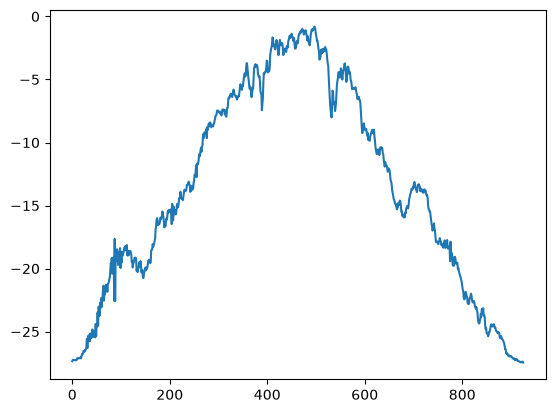

In [86]:
plt.plot(results[next(iter(results))]["second"], results[next(iter(results))]["power_db"])
plt.show()

In [87]:
power_df = results[next(iter(results))]

power_altaz_df = df_altaz.merge(
    power_df,
    left_on="elapsed_s",
    right_on="second",
    how="inner",
)

print(power_altaz_df.head())

                              time     unix_time  elapsed_s      az_deg  \
0 2026-10-01 11:24:37.520197+00:00  1.790854e+09        0.0  162.258350   
1 2026-10-01 11:24:38.520197+00:00  1.790854e+09        1.0  162.262944   
2 2026-10-01 11:24:39.520197+00:00  1.790854e+09        2.0  162.267548   
3 2026-10-01 11:24:40.520197+00:00  1.790854e+09        3.0  162.272160   
4 2026-10-01 11:24:41.520197+00:00  1.790854e+09        4.0  162.276783   

    alt_deg     range_km  second  power_linear   power_db            iq_file  
0 -0.001568  3345.509485       0      0.001841 -27.348533  59051_baseband.iq  
1  0.058624  3338.849043       1      0.001883 -27.252275  59051_baseband.iq  
2  0.118937  3332.188633       2      0.001890 -27.235676  59051_baseband.iq  
3  0.179371  3325.528260       3      0.001883 -27.251249  59051_baseband.iq  
4  0.239928  3318.867935       4      0.001882 -27.253421  59051_baseband.iq  


In [88]:
def polar_plot(*dfs, name="", color_range=(-30, 0)):
    fig = plt.figure(figsize=(16, 16))
    ax = plt.subplot(111, polar=True)

    for df in dfs:
        # Convert elevation to radial distance
        alts = 90 - df["alt_deg"].to_numpy()
        azs = np.radians(df["az_deg"].to_numpy())
        power = df["power_db"].to_numpy()

        ax.scatter(
            azs,
            alts,
            c=power,
            cmap="turbo",
            vmin=color_range[0],
            vmax=color_range[1],
            s=10,
        )

    ax.set_theta_zero_location("N")
    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(0, 90)

    ax.set_yticks(range(0, 91, 30))
    ax.set_yticklabels(range(90, -1, -30))

    ax.set_xticks(np.radians(range(0, 360, 30)))

    ax.set_title(name)

    #cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
    #cbar.set_label("Power (dB)")

    return fig

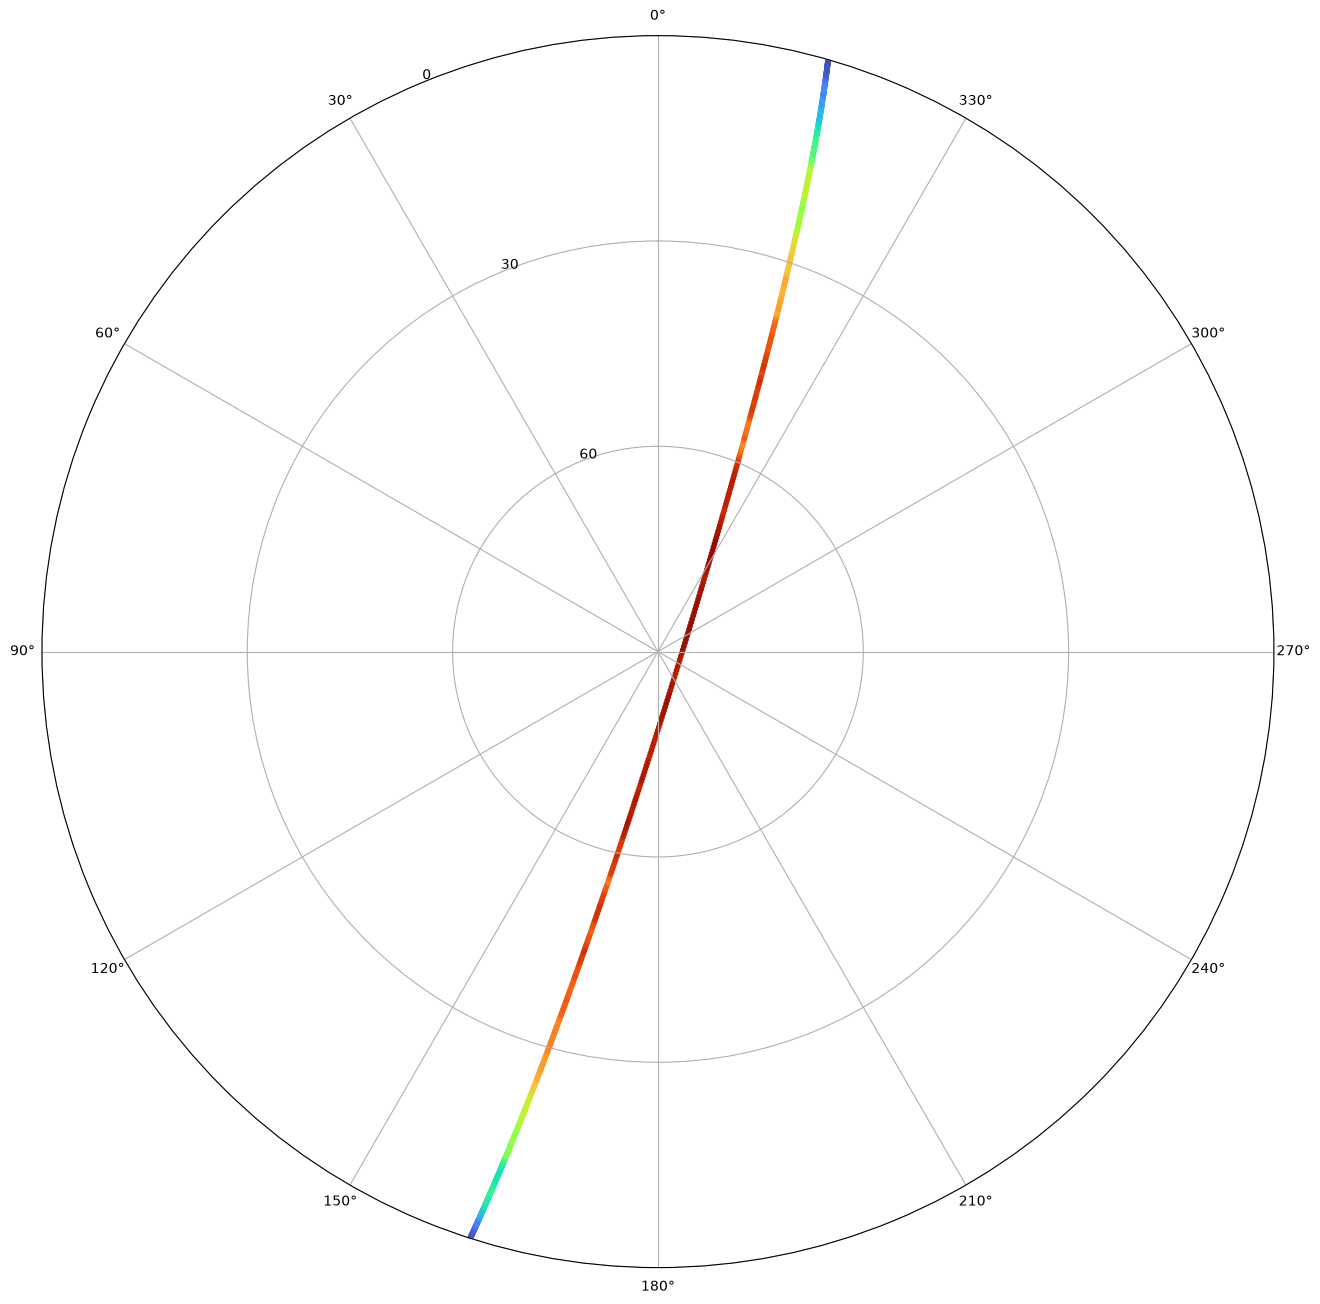

In [89]:
fig = polar_plot(power_altaz_df)
plt.show()